In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: E:\Final_Year_Project\gnn_env\Scripts\python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv("E:/Final_Year_Project/data/external/gdsc/gdsc_ic50_raw.csv")

print(df.columns)
print(df.shape)

Index(['Drug Name', 'Drug ID', 'Cell Line Name', 'Cosmic ID',
       'TCGA Classification', 'Tissue', 'Tissue Sub-type', 'IC50', 'AUC',
       'Max Conc', 'RMSE', 'Z score', 'Dataset Version'],
      dtype='object')
(243466, 13)


In [4]:
GDSC_PATH = r"E:\Final_Year_Project\data\external\gdsc\gdsc_ic50_raw.csv"

gdsc = pd.read_csv(GDSC_PATH)

print("Original shape:", gdsc.shape)

gdsc_breast = gdsc[gdsc["Tissue"].str.lower() == "breast"].copy()

print("Breast-only shape:", gdsc_breast.shape)

Original shape: (243466, 13)
Breast-only shape: (13471, 13)


In [5]:
gdsc_breast = gdsc_breast.dropna(subset=["IC50"])
print("After cleaning:", gdsc_breast.shape)

After cleaning: (13471, 13)


In [6]:
cellline_mean_ic50 = (
    gdsc_breast
    .groupby("Cell Line Name")["IC50"]
    .mean()
    .reset_index()
)

print("Unique breast cell lines:", cellline_mean_ic50.shape[0])
cellline_mean_ic50.head()

Unique breast cell lines: 52


,Cell Line Name,IC50
0,AU565,2.512223
1,BT-20,3.027204
2,BT-474,4.164491
3,BT-483,5.576851
4,BT-549,3.386720


In [7]:
# Sort by sensitivity
cellline_mean_ic50 = cellline_mean_ic50.sort_values("IC50")

# Split into 3 equal groups
n = len(cellline_mean_ic50)

cellline_mean_ic50["Subtype"] = "Moderate-like"

cellline_mean_ic50.iloc[: n//3, 1]  # just preview

11    1.411154
26    1.961374
14    2.006885
6     2.049206
46    2.176186
43    2.195955
27    2.198645
42    2.314210
23    2.316257
45    2.326473
21    2.482019
32    2.497588
0     2.512223
7     2.521002
40    2.686175
17    2.688385
39    2.753307
Name: IC50, dtype: float64

In [8]:
cellline_mean_ic50.iloc[: n//3, cellline_mean_ic50.columns.get_loc("Subtype")] = "Aggressive-like"
cellline_mean_ic50.iloc[n//3 : 2*n//3, cellline_mean_ic50.columns.get_loc("Subtype")] = "Moderate-like"
cellline_mean_ic50.iloc[2*n//3 :, cellline_mean_ic50.columns.get_loc("Subtype")] = "Indolent-like"

cellline_mean_ic50.head()

,Cell Line Name,IC50,Subtype
11,DU-4475,1.411154,Aggressive-like
26,HCC202,1.961374,Aggressive-like
14,EVSA-T,2.006885,Aggressive-like
6,CAL-148,2.049206,Aggressive-like
46,OCUB-M,2.176186,Aggressive-like


In [9]:
gdsc_breast = gdsc_breast.merge(
    cellline_mean_ic50[["Cell Line Name", "Subtype"]],
    on="Cell Line Name"
)

gdsc_breast.head()

,Drug Name,Drug ID,Cell Line Name,Cosmic ID,TCGA Classification,Tissue,Tissue Sub-type,IC50,AUC,Max Conc,RMSE,Z score,Dataset Version,Subtype
0,Camptothecin,1003,HCC1954,749709,BRCA,breast,breast,0.317741,0.983262,0.1,0.082831,1.403164,GDSC2,Moderate-like
1,Camptothecin,1003,HCC1143,749710,BRCA,breast,breast,0.636184,0.969050,0.1,0.077198,1.576546,GDSC2,Indolent-like
2,Camptothecin,1003,HCC1187,749711,BRCA,breast,breast,1.235544,0.992326,0.1,0.079605,1.902878,GDSC2,Moderate-like
3,Camptothecin,1003,HCC1395,749712,BRCA,breast,breast,-2.255899,0.861208,0.1,0.096794,0.001898,GDSC2,Aggressive-like
4,Camptothecin,1003,HCC1599,749713,BRCA,breast,breast,-3.247021,0.768404,0.1,0.111973,-0.537737,GDSC2,Moderate-like


In [10]:
drug_subtype_ranking = (
    gdsc_breast
    .groupby(["Subtype", "Drug Name"])["IC50"]
    .mean()
    .reset_index()
)

drug_subtype_ranking.head()

,Subtype,Drug Name,IC50
0,Aggressive-like,123138,2.375771
1,Aggressive-like,123829,1.054167
2,Aggressive-like,150412,2.358775
3,Aggressive-like,5-Fluorouracil,4.322560
4,Aggressive-like,5-azacytidine,2.360036


In [11]:
global_min = drug_subtype_ranking["IC50"].min()
global_max = drug_subtype_ranking["IC50"].max()

drug_subtype_ranking["Compatibility Score"] = 1 - (
    (drug_subtype_ranking["IC50"] - global_min) /
    (global_max - global_min + 1e-9)
)

final_rankings = drug_subtype_ranking.sort_values(
    ["Subtype", "Compatibility Score"],
    ascending=[True, False]
).reset_index(drop=True)

final_rankings.head(10)

,Subtype,Drug Name,IC50,Compatibility Score
0,Aggressive-like,Romidepsin,-5.506018,1.000000
1,Aggressive-like,Bortezomib,-5.237962,0.983687
2,Aggressive-like,Docetaxel,-4.661225,0.948587
3,Aggressive-like,Vinblastine,-4.449487,0.935701
4,Aggressive-like,Eg5_9814,-4.166314,0.918468
5,Aggressive-like,Dactinomycin,-4.067833,0.912474
6,Aggressive-like,SN-38,-3.987580,0.907590
7,Aggressive-like,Sepantronium bromide,-3.873119,0.900624
8,Aggressive-like,Paclitaxel,-3.808596,0.896698
9,Aggressive-like,Rapamycin,-3.721885,0.891421


In [12]:
for subtype in final_rankings["Subtype"].unique():
    print("\nTop 5 for", subtype)
    display(
        final_rankings[final_rankings["Subtype"] == subtype]
        .head(5)
    )


Top 5 for Aggressive-like


,Subtype,Drug Name,IC50,Compatibility Score
0,Aggressive-like,Romidepsin,-5.506018,1.000000
1,Aggressive-like,Bortezomib,-5.237962,0.983687
2,Aggressive-like,Docetaxel,-4.661225,0.948587
3,Aggressive-like,Vinblastine,-4.449487,0.935701
4,Aggressive-like,Eg5_9814,-4.166314,0.918468



Top 5 for Indolent-like


,Subtype,Drug Name,IC50,Compatibility Score
288,Indolent-like,Bortezomib,-4.631287,0.946765
289,Indolent-like,Romidepsin,-4.556911,0.942239
290,Indolent-like,Sepantronium bromide,-3.642846,0.886610
291,Indolent-like,Dactinomycin,-1.945458,0.783310
292,Indolent-like,Eg5_9814,-1.749224,0.771368



Top 5 for Moderate-like


,Subtype,Drug Name,IC50,Compatibility Score
566,Moderate-like,Romidepsin,-5.226012,0.982959
567,Moderate-like,Bortezomib,-4.967254,0.967212
568,Moderate-like,Sepantronium bromide,-4.068327,0.912504
569,Moderate-like,Dactinomycin,-3.372555,0.870161
570,Moderate-like,Dinaciclib,-2.872054,0.839701


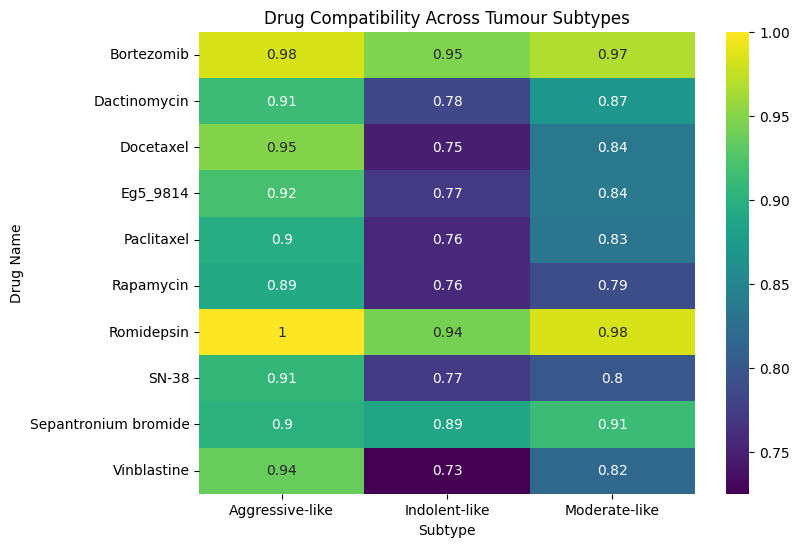

In [13]:
import seaborn as sns

# Get top 10 drugs overall (to compare across subtypes)
top_drugs = (
    final_rankings
    .groupby("Drug Name")["Compatibility Score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

heatmap_df = final_rankings[
    final_rankings["Drug Name"].isin(top_drugs)
]

pivot_table = heatmap_df.pivot(
    index="Drug Name",
    columns="Subtype",
    values="Compatibility Score"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, cmap="viridis")
plt.title("Drug Compatibility Across Tumour Subtypes")
plt.show()

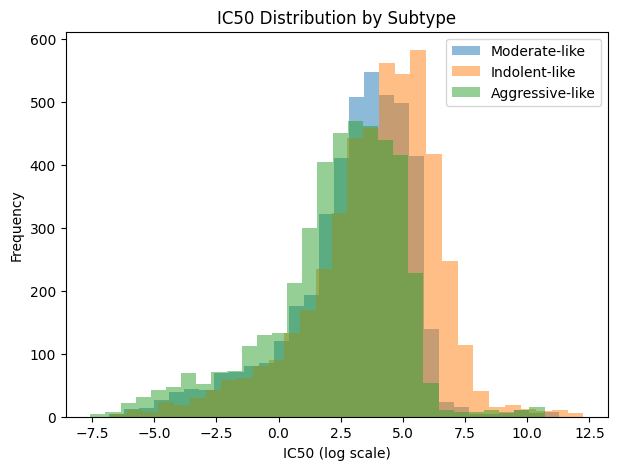

In [14]:
plt.figure(figsize=(7,5))

for subtype in gdsc_breast["Subtype"].unique():
    subset = gdsc_breast[gdsc_breast["Subtype"] == subtype]
    plt.hist(subset["IC50"], bins=30, alpha=0.5, label=subtype)

plt.legend()
plt.title("IC50 Distribution by Subtype")
plt.xlabel("IC50 (log scale)")
plt.ylabel("Frequency")
plt.show()

In [15]:
SAVE_DIR = r"E:\Final_Year_Project\outputs\drug_ranking"
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = os.path.join(SAVE_DIR, "subtype_specific_drug_ranking.csv")

final_rankings.to_csv(save_path, index=False)

print("Subtype-specific ranking saved at:", save_path)

Subtype-specific ranking saved at: E:\Final_Year_Project\outputs\drug_ranking\subtype_specific_drug_ranking.csv
